# 3. Similarity Analysis

This notebook analyzes semantic similarity between political manifestos.

We compare:
- TF-IDF (lexical similarity)
- Sentence embeddings (semantic similarity)

We also perform a ranking task to evaluate how well embeddings capture meaningful relationships.

In [79]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np

## 3.1 Loading the dataset

In [80]:
folder = "/content/text_files/1988/legislatives"

data = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        with open(os.path.join(folder, filename), "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        data.append({"id": filename, "text": text})

df = pd.DataFrame(data)

print("Number of documents:", len(df))

Number of documents: 3628


## 3.2 Text preprocessing

In [81]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

In [82]:
df_sample = df.sample(n=500, random_state=42).reset_index(drop=True)

## 3.3 TF-IDF baseline

In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)

tfidf_matrix = vectorizer.fit_transform(df_sample["clean_text"])

In [84]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_sim = cosine_similarity(tfidf_matrix)

## 3.4 Embedding representation

In [85]:
!pip install sentence-transformers

In [86]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = df_sample["clean_text"].tolist()

embeddings = model.encode(texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [87]:
emb_sim = cosine_similarity(embeddings)

## 3.5 Similarity heatmap

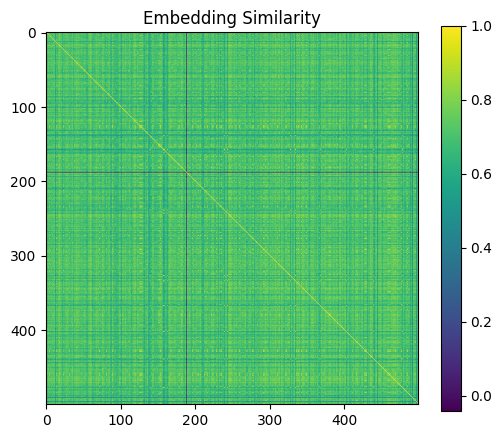

In [88]:
plt.figure(figsize=(6,5))
plt.imshow(emb_sim, cmap="viridis")
plt.colorbar()
plt.title("Embedding Similarity")
plt.show()

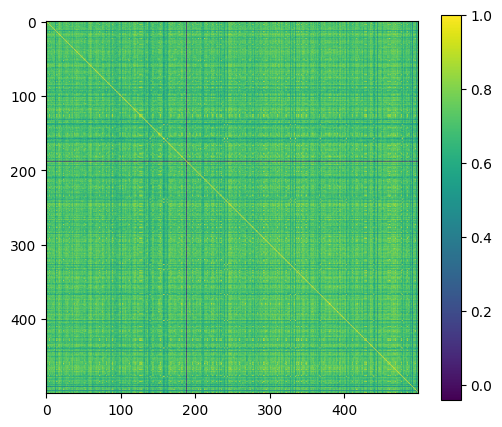

In [89]:
plt.figure(figsize=(6,5))
plt.imshow(emb_sim, cmap="viridis")
plt.colorbar()
plt.savefig("similarity_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.6 Document Ranking

In [90]:
def get_top_k(sim_matrix, idx, k=3):
    scores = sim_matrix[idx]
    return scores.argsort()[::-1][1:k+1]

In [91]:
query_idx = 0
top_k = 3

top_emb = get_top_k(emb_sim, query_idx, k=top_k)
top_tfidf = get_top_k(tfidf_sim, query_idx, k=top_k)

In [92]:
print("Query ID:", df_sample.iloc[query_idx]["id"])

print("\nTop Embedding Matches:")
for i, idx in enumerate(top_emb):
    print(f"{i+1}. {df_sample.iloc[idx]['id']}")

print("\nTop TF-IDF Matches:")
for i, idx in enumerate(top_tfidf):
    print(f"{i+1}. {df_sample.iloc[idx]['id']}")

Query ID: EL176_L_1988_06_059_02_1_PF_04.txt

Top Embedding Matches:
1. EL176_L_1988_06_059_02_2_PF_02.txt
2. EL174_L_1988_06_014_06_1_PF_03.txt
3. EL175_L_1988_06_031_04_1_PF_01.txt

Top TF-IDF Matches:
1. EL176_L_1988_06_059_02_2_PF_02.txt
2. EL177_L_1988_06_094_03_1_PF_07.txt
3. EL175_L_1988_06_053_01_2_PF_01.txt


In [93]:
def preview(text, n=800):
    return text[:n] + "..."

In [94]:
print("QUERY TEXT:\n")
print(preview(df_sample.iloc[query_idx]["text"]))

print("\n\nEMBEDDING RESULT:\n")
print(preview(df_sample.iloc[top_emb[0]]["text"]))

print("\n\nTF-IDF RESULT:\n")
print(preview(df_sample.iloc[top_tfidf[0]]["text"]))

QUERY TEXT:

ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988 2e CIRCONSCRIPTION
UNION du RASSEMBLEMENT et du CENTRE URC
Désiré VANBRABANT
Pierre RETUREAU
Sciences Po / fonds CEVIPOF
Je suis né à Ronchin le 29 avril 1935.
Je suis veuf ; j'ai un enfant, ce qui m'a amené à être durant huit années responsable de parents d'élèves. Je participe encore, pour un filleul, à l'association de parents d'un Lyçée Technique, j'ai aussi un petit fils.
Artisans en restauration de demeures anciennes, j'ai été pendant trois années, le Président de l'Umion Commerciale de Ronchin, avant d'en être le Président d'Honneur.
Je suis né à Angers et habite depuis 29 ans dans la métropole.
Marié, cinq enfants (8 petits enfants). Ingénieur commercial HEC, licencié en Droit, Docteur es - sciences - Eco
Actuellement retraité après avoi...


EMBEDDING RESULT:

Sciences Po / fonds CEVIPOF
ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988 2e CIRCONSCRIPTION
UNION du RASSEMBLEMENT et du CENTRE URC
Désiré VANBRABANT
Je suis né à

In [95]:
for i, idx in enumerate(top_emb):
    print(f"\n--- EMBEDDING DOC {i+1} ---")
    print(preview(df_sample.iloc[idx]["text"], 500))


--- EMBEDDING DOC 1 ---
Sciences Po / fonds CEVIPOF
ELECTIONS LEGISLATIVES DES 5 ET 12 JUIN 1988 2e CIRCONSCRIPTION
UNION du RASSEMBLEMENT et du CENTRE URC
Désiré VANBRABANT
Je suis né à Ronchin le 29 avril 1935.
Je suis veuf ; j'ai un enfant, ce qui m'a amené à être durant huit années responsable de parents d'élèves. Je participe encore, pour un filleul, à l'association de parents d'un Lyçée Technique, j'ai aussi un petit fils.
Artisan en restauration de demeures anciennes, j'ai été pendant trois années, le Président ...

--- EMBEDDING DOC 2 ---
Sciences Po / fonds CEVIPOF
ÉLECTIONS LÉGISLATIVES DU 5 JUIN 1988 - Département du Calvados - 6e Circonscription
René GARREC
Conseiller Général Président du Conseil Régional Officier de la Légion d'honneur Médaille de la Valeur Militaire
Madame, Mademoiselle, Monsieur,
L'état de la France d'aujourd'hui, ses problèmes nous in- quiètent tous.
Nos principaux soucis, nous les connaissons :
· Pour nos enfants, nous demandons une école qui leur app

## 3.7 PCA visualization

In [96]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

df_sample["pca_1"] = reduced[:,0]
df_sample["pca_2"] = reduced[:,1]

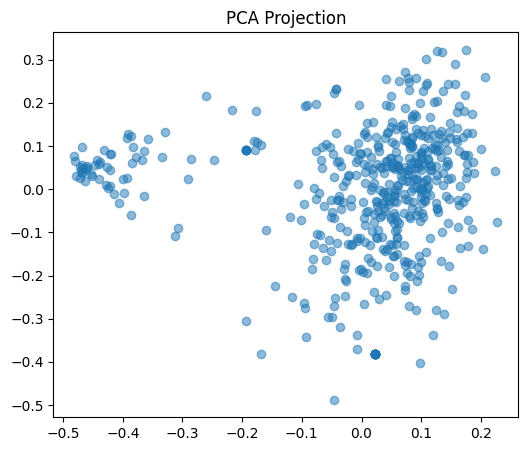

In [97]:
plt.figure(figsize=(6,5))
plt.scatter(df_sample["pca_1"], df_sample["pca_2"], alpha=0.5)
plt.title("PCA Projection")
plt.show()

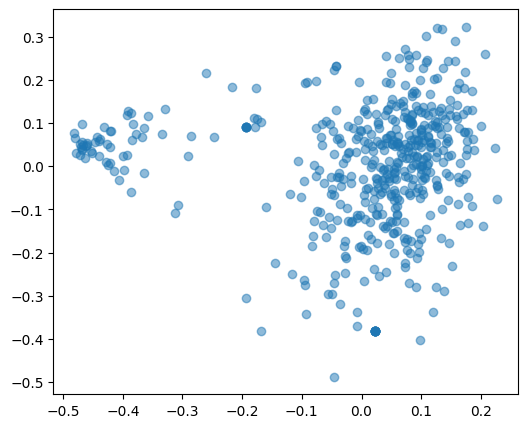

In [98]:
plt.figure(figsize=(6,5))
plt.scatter(df_sample["pca_1"], df_sample["pca_2"], alpha=0.5)
plt.savefig("pca_embeddings.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.8 Similarity distribution

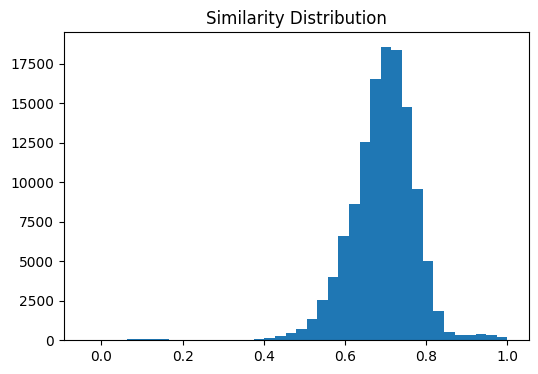

In [99]:
values = emb_sim[np.triu_indices_from(emb_sim, k=1)]

plt.figure(figsize=(6,4))
plt.hist(values, bins=40)
plt.title("Similarity Distribution")
plt.show()

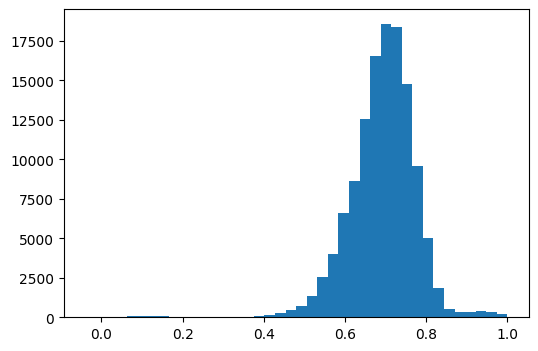

In [100]:
plt.figure(figsize=(6,4))
plt.hist(values, bins=40)
plt.savefig("similarity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.9 Summary

Embedding-based similarity captures deeper relationships between documents compared to TF-IDF.

The ranking results show that semantically related documents can be retrieved even without lexical overlap.

The PCA visualization suggests that documents exhibit structure in semantic space.